<a href="https://colab.research.google.com/github/savirpatil/neural-networks-basics/blob/main/makemore_bigrams.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
words = [word.lower() for word in open('/content/names.txt', 'r').read().splitlines()]

In [4]:
b = {}
for w in words:
  w = w.lower()
  chs = ['<S>'] + list(w) + ['<E>']
  for ch1, ch2 in zip(chs, chs[1:]):
    bigram = (ch1, ch2)
    b[bigram] = b.get(bigram, 0) + 1

sorted(b.items(), key = lambda kv: -kv[1])

[(('a', 'n'), 25646),
 (('h', 'a'), 18167),
 (('a', '<E>'), 16312),
 (('t', 'h'), 15185),
 (('s', 'h'), 14246),
 (('n', '<E>'), 13513),
 (('a', 'r'), 10752),
 (('r', 'a'), 10543),
 (('i', '<E>'), 8863),
 (('h', 'i'), 8170),
 (('n', 'a'), 7889),
 (('y', 'a'), 7506),
 (('n', 'i'), 6941),
 (('k', 'a'), 6619),
 (('<S>', 'a'), 6476),
 (('v', 'a'), 6045),
 (('m', 'a'), 5546),
 (('a', 's'), 5382),
 (('a', 't'), 5185),
 (('i', 'n'), 5154),
 (('<S>', 's'), 5140),
 (('r', 'i'), 4935),
 (('i', 't'), 4881),
 (('h', '<E>'), 4551),
 (('l', 'a'), 4496),
 (('a', 'a'), 4483),
 (('v', 'i'), 4469),
 (('i', 's'), 4328),
 (('<S>', 'k'), 4233),
 (('e', 'e'), 4232),
 (('s', 'a'), 4203),
 (('<S>', 'v'), 4106),
 (('<S>', 'm'), 3849),
 (('a', 'm'), 3845),
 (('a', 'l'), 3842),
 (('a', 'v'), 3635),
 (('<S>', 'n'), 3551),
 (('e', 's'), 3516),
 (('<S>', 'r'), 3353),
 (('j', 'a'), 3343),
 (('i', 'k'), 3324),
 (('<S>', 'p'), 3289),
 (('d', 'h'), 3034),
 (('n', 't'), 3025),
 (('e', 'n'), 3011),
 (('<S>', 'd'), 2965),


In [2]:
import torch

In [5]:
N = torch.zeros((27, 27), dtype=torch.int32)

In [6]:
chars = sorted(list(set(''.join(words))))
stoi = { s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = { i:s for s,i in stoi.items()}

In [7]:
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1, ix2] += 1

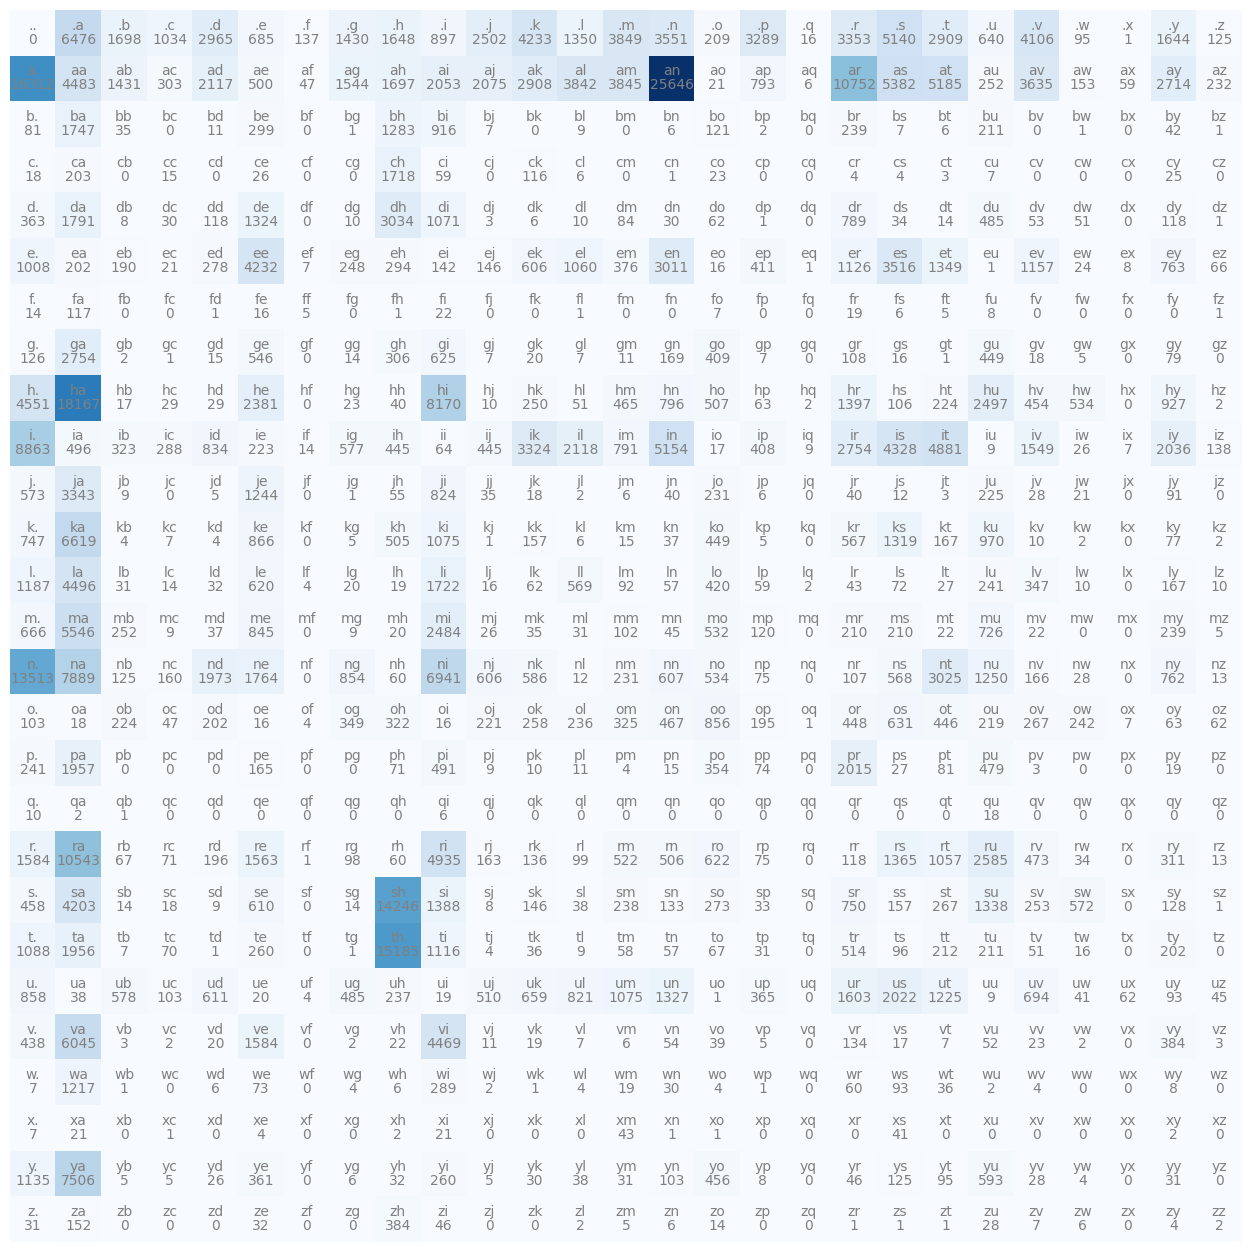

In [8]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [14]:
P = (N+1).float()
P /= P.sum(1, keepdim=True)

In [15]:
g = torch.Generator().manual_seed(2147483647)

for i in range(10):
  out = []
  ix = 0
  while True:
    p = P[ix]
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))


deeba.
pogakurari.
jitaharvinimithain.
lanak.
kan.
a.
sa.
ripubatharugothi.
mi.
jeelavuja.


In [16]:
log_likelihood = 0.0
n = 0

for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    prob = P[ix1, ix2]
    logprob = torch.log(prob)
    log_likelihood += logprob
    n += 1
    #print(f'{ch1}{ch1}: {prob:.4f} {logprob: .4f}')

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

log_likelihood=tensor(-1061526.3750)
nll=tensor(1061526.3750)
2.174929141998291


In [18]:
# create the training set of bigrams (x,y)
xs, ys = [], []

for w in words[:1]:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    print(ch1, ch2)
    xs.append(ix1)
    ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)

. a
a a
a b
b a
a n
n .


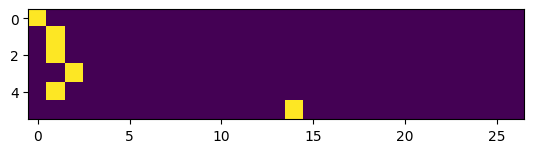

In [21]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27).float()
#xenc
plt.imshow(xenc)

In [23]:
W = torch.randn((27, 27))
xenc @ W

tensor([[-0.4243, -0.1477, -0.6477,  0.3303, -0.8300, -0.5883,  1.9782,  0.3855,
          0.1380,  0.2388, -1.7868,  0.7732,  0.0802, -0.6502, -0.0288,  1.4851,
         -1.8318, -0.3848,  0.6168,  0.3384,  1.2831, -0.2224, -0.3639,  1.8459,
         -0.0457, -0.4408,  2.1981],
        [-0.3442,  1.5175, -0.0272,  1.6146,  1.0757,  0.7376,  0.1282,  0.4883,
          1.2169,  1.9314,  0.3732, -0.7370, -0.4683, -0.1130,  0.3582,  0.5594,
         -1.0245, -1.0015, -1.6411,  0.0610, -0.3896,  1.2902, -1.3181, -1.2804,
          0.4663, -2.0512,  0.4598],
        [-0.3442,  1.5175, -0.0272,  1.6146,  1.0757,  0.7376,  0.1282,  0.4883,
          1.2169,  1.9314,  0.3732, -0.7370, -0.4683, -0.1130,  0.3582,  0.5594,
         -1.0245, -1.0015, -1.6411,  0.0610, -0.3896,  1.2902, -1.3181, -1.2804,
          0.4663, -2.0512,  0.4598],
        [-1.4481,  0.4976, -1.5465,  0.6650,  2.4635,  0.6977, -0.5808, -1.1045,
         -0.2206, -0.1993, -0.1399, -0.5290, -1.6646, -0.4056, -2.1725,  0.1423

In [24]:
logits = xenc @ W # log-counts
counts = logits.exp() # equivalent N
probs = counts / counts.sum(1, keepdims=True)
probs

tensor([[0.0128, 0.0169, 0.0103, 0.0273, 0.0085, 0.0109, 0.1417, 0.0288, 0.0225,
         0.0249, 0.0033, 0.0425, 0.0212, 0.0102, 0.0190, 0.0866, 0.0031, 0.0133,
         0.0363, 0.0275, 0.0707, 0.0157, 0.0136, 0.1242, 0.0187, 0.0126, 0.1766],
        [0.0154, 0.0989, 0.0211, 0.1090, 0.0636, 0.0453, 0.0247, 0.0353, 0.0732,
         0.1496, 0.0315, 0.0104, 0.0136, 0.0194, 0.0310, 0.0379, 0.0078, 0.0080,
         0.0042, 0.0231, 0.0147, 0.0788, 0.0058, 0.0060, 0.0346, 0.0028, 0.0343],
        [0.0154, 0.0989, 0.0211, 0.1090, 0.0636, 0.0453, 0.0247, 0.0353, 0.0732,
         0.1496, 0.0315, 0.0104, 0.0136, 0.0194, 0.0310, 0.0379, 0.0078, 0.0080,
         0.0042, 0.0231, 0.0147, 0.0788, 0.0058, 0.0060, 0.0346, 0.0028, 0.0343],
        [0.0064, 0.0446, 0.0058, 0.0528, 0.3187, 0.0545, 0.0152, 0.0090, 0.0218,
         0.0222, 0.0236, 0.0160, 0.0051, 0.0181, 0.0031, 0.0313, 0.0533, 0.0349,
         0.0565, 0.0145, 0.0737, 0.0190, 0.0112, 0.0210, 0.0133, 0.0390, 0.0155],
        [0.0154, 0.0989,

In [25]:
# SUMMARY ------------------------------>>>>

In [26]:
xs

tensor([ 0,  1,  1,  2,  1, 14])

In [27]:
ys

tensor([ 1,  1,  2,  1, 14,  0])

In [28]:
# randomly initialize 27 neurons' weights. each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g)

In [31]:
xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
logits = xenc @ W # predict log-counts
counts = logits.exp() # counts, equivalent to N
probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
# last 2 lines here are together called a 'softmax'

In [33]:
nlls = torch.zeros(6)
for i in range(6):
  # i-th bigram:
  x = xs[i].item() # input character index
  y = ys[i].item() # label character index
  print('--------')
  print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y})')
  print('input to the neural net:', x)
  print('output probabilities from the neural net:', probs[i])
  print('label (actual next character):', y)
  p = probs[i, y]
  print('probability assigned by the net to the the correct character:', p.item())
  logp = torch.log(p)
  print('log likelihood:', logp.item())
  nll = -logp
  print('negative log likelihood:', nll.item())
  nlls[i] = nll

print('=========')
print('average negative log likelihood, i.e. loss =', nlls.mean().item())

--------
bigram example 1: .a (indexes 0,1)
input to the neural net: 0
output probabilities from the neural net: tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459])
label (actual next character): 1
probability assigned by the net to the the correct character: 0.009982486255466938
log likelihood: -4.6069231033325195
negative log likelihood: 4.6069231033325195
--------
bigram example 2: aa (indexes 1,1)
input to the neural net: 1
output probabilities from the neural net: tensor([0.0150, 0.0086, 0.0396, 0.0100, 0.0606, 0.0308, 0.1084, 0.0131, 0.0125,
        0.0048, 0.1024, 0.0086, 0.0988, 0.0112, 0.0232, 0.0207, 0.0408, 0.0078,
        0.0899, 0.0531, 0.0463, 0.0309, 0.0051, 0.0329, 0.0654, 0.0503, 0.0091])
label (actual next character): 1
probability assigned by the net to the the correct character: 0

In [34]:
# --------- OPTIMIZATION --------------

In [43]:
# randomly initialize 27 neurons' weights. each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

In [44]:
# forward pass
xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
logits = xenc @ W # predict log-counts
counts = logits.exp() # counts, equivalent to N
probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
loss = -probs[torch.arange(6), ys].log().mean()
print(loss.item())

3.8419463634490967


In [45]:
# backward pass
W.grad = None # set to zero the gradient
loss.backward()
W.data += -0.1 * W.grad

In [46]:
# --------- OPTIMIZATION, but this time actually --------------

In [47]:
# create the dataset
xs, ys = [], []
for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    xs.append(ix1)
    ys.append(ix2)
xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

# initialize the 'network'
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

number of examples:  488074


In [58]:
# gradient descent
for k in range(1):

  # forward pass
  xenc = F.one_hot(xs, num_classes=27).float() # input to the network: one-hot encoding
  logits = xenc @ W # predict log-counts
  counts = logits.exp() # counts, equivalent to N
  probs = counts / counts.sum(1, keepdims=True) # probabilities for next character
  loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean()
  print(loss.item())

  # backward pass
  W.grad = None # set to zero the gradient
  loss.backward()

  # update
  W.data += -50 * W.grad

2.4068126678466797


In [61]:
# finally, sample from the 'neural net' model
g = torch.Generator().manual_seed(2147483647)

for i in range(10):

  out = []
  ix = 0
  while True:

    # ----------
    # BEFORE:
    #p = P[ix]
    # ----------
    # NOW:
    xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
    logits = xenc @ W # predict log-counts
    counts = logits.exp() # counts, equivalent to N
    p = counts / counts.sum(1, keepdims=True) # probabilities for next character
    # ----------

    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

dexzmaroglaurari.
zkayharpozishanarn.
lgavkzkan.
a.
sa.
xthucjanhi.
gothi.
mblashaniuja.
preda.
ka.
